# Task 0: Download the required libraries

In [1]:
# Install the core library
!pip install torch_geometric

# Install the versions strictly matching your PyTorch version
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv pyg_lib -f https://data.pyg.org/whl/torch-{version}.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.2 MB/s eta 0:00:00a 0:00:01
Looking in links: https://data.pyg.org/whl/torch-{version}.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib


# Task 1+2: Prepare the dataset and create the GIN network

In [54]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
import torch_geometric.transforms as T
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import time
import psutil
import os
import numpy as np


# === CONFIGURATION ===
DATASET_NAME = 'IMDB-MULTI' # Options: 'MUTAG', 'ENZYMES', 'IMDB-MULTI'
BATCH_SIZE = 32  
HIDDEN_DIM = 32 # Embedding size
DROPOUT = 0.15  
EPOCHS = 1000


# === DATA PREPARATION ===
def get_dataset(name):
    if name == 'IMDB-MULTI':
        transform = T.OneHotDegree(max_degree=150) 
    else:
        transform = None

    dataset = TUDataset(root='/tmp/' + name, name=name, pre_transform=transform)
    
    torch.manual_seed(12345)
    dataset = dataset.shuffle()
    train_dataset = dataset[:int(len(dataset) * 0.8)]
    test_dataset = dataset[int(len(dataset) * 0.8):]
    
    return dataset, train_dataset, test_dataset

dataset, train_dataset, test_dataset = get_dataset(DATASET_NAME)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset: {DATASET_NAME}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of features: {dataset.num_features}")
print(f"Embedding dimensions: {HIDDEN_DIM}")
print("============================================\n")


# === GIN MODEL ARCHITECTURE ===
class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super(GIN, self).__init__()
        self.dropout = dropout
        # GIN layers expect a Neural Network (MLP) as the internal update function
        # GINConv() tells every node to look at their neighbors and add their numbers to theirs
        # Once a node aggregates info from neighbors, the MLP learns how to transform that neighbor data into something useful.
        # Layer 1: Node knows about its immediate neighbors.
        # Layer 2: Node knows about neighbors of neighbors (2 hops away).
        # Layer 3: Node knows about the whole neighborhood (3 hops away).
        
        # Layer 1
        self.mlp1 = Sequential(
            Linear(in_channels, hidden_channels), 
            BatchNorm1d(hidden_channels), 
            ReLU(),
            Linear(hidden_channels, hidden_channels), 
            ReLU()
        )
        self.conv1 = GINConv(self.mlp1)
        
        # Layer 2
        self.mlp2 = Sequential(
            Linear(hidden_channels, hidden_channels), 
            BatchNorm1d(hidden_channels), 
            ReLU(),
            Linear(hidden_channels, hidden_channels), 
            ReLU()
        )
        self.conv2 = GINConv(self.mlp2)
        
        # Layer 3
        self.mlp3 = Sequential(
            Linear(hidden_channels, hidden_channels), 
            BatchNorm1d(hidden_channels), 
            ReLU(),
            Linear(hidden_channels, hidden_channels), 
            ReLU()
        )
        self.conv3 = GINConv(self.mlp3)

        # Final Classifier
        self.lin_class = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = x.relu()

        # Readout layer (Pooling)
        # Aggregates all node embeddings into 1 graph embedding
        graph_embedding = global_add_pool(x, batch)

        # Final Classifier
        # Apply a final linear layer for classification
        out = self.lin_class(graph_embedding)
        
        # Return Log-Softmax (for Loss), Softmax (for AUC), and Embedding
        return F.log_softmax(out, dim=1), F.softmax(out, dim=1), graph_embedding

Processing...


Dataset: IMDB-MULTI
Number of graphs: 1500
Number of classes: 3
Number of features: 151
Embedding dimensions: 32



Done!


# Task 3A: Classification 

In [55]:
# === SETUP ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GIN(dataset.num_features, HIDDEN_DIM, dataset.num_classes, DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        # We use log_softmax (out[0]) for NLL Loss
        out, _, _ = model(data.x, data.edge_index, data.batch)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def test(loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = [] # Needed for AUC
    embeddings_list = []
    
    for data in loader:
        data = data.to(device)
        _, probs, embeddings = model(data.x, data.edge_index, data.batch)
        
        pred = probs.argmax(dim=1)
        
        all_preds.append(pred.cpu().detach())
        all_labels.append(data.y.cpu().detach())
        all_probs.append(probs.cpu().detach())
        embeddings_list.append(embeddings.cpu().detach())

    # Concatenate for metric calculation
    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_true = torch.cat(all_labels, dim=0).numpy()
    y_probs = torch.cat(all_probs, dim=0).numpy()
    final_embeddings = torch.cat(embeddings_list, dim=0)
    
    return y_true, y_pred, y_probs, final_embeddings


# === HELPER: MEMORY TRACKING ===
def get_memory_usage():
    # Returns memory usage in MB
    if torch.cuda.is_available():
        # GPU Memory
        return torch.cuda.max_memory_allocated() / 1024 / 1024
    else:
        # CPU Memory
        process = psutil.Process(os.getpid())
        return process.memory_info().rss / 1024 / 1024


# === EXECUTION & METRIC CALCULATION ===
print(f"Starting training on {device}...")

# Measure Training Time
start_train = time.time()
if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

for epoch in range(1, EPOCHS + 1):
    loss = train()
    if epoch % 10 == 0:
        y_true_monitor, y_pred_monitor, _, _ = test(test_loader)
        acc_monitor = accuracy_score(y_true_monitor, y_pred_monitor)
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {acc_monitor:.4f}')

end_train = time.time()
training_time = end_train - start_train

# Measure Memory Usage (Peak during training)
memory_used = get_memory_usage()

# Measure Generation (Inference) Time
start_gen = time.time()
y_true, y_pred, y_probs, final_embeddings = test(test_loader)
end_gen = time.time()
generation_time = end_gen - start_gen

# Calculate Detailed Metrics
# Accuracy
acc = accuracy_score(y_true, y_pred)

# F1 Score (Handle binary vs multi-class)
if dataset.num_classes == 2:
    f1 = f1_score(y_true, y_pred, average='binary')
    # AUC for binary needs probability of the positive class (column 1)
    try:
        auc = roc_auc_score(y_true, y_probs[:, 1])
    except:
        auc = 0.0 # Handle edge cases
else:
    f1 = f1_score(y_true, y_pred, average='weighted')
    # AUC for multi-class needs One-vs-Rest strategy
    try:
        auc = roc_auc_score(y_true, y_probs, multi_class='ovr')
    except:
        auc = 0.0

print("\n" + "="*40)
print("FINAL RESULTS REPORT")
print("="*40)
print(f"Method: GIN (Graph Isomorphism Network)")
print(f"Dataset: {DATASET_NAME}")
print("-" * 20)
print(f"Classification Accuracy : {acc:.4f}")
print(f"F1-Score                : {f1:.4f}")
print(f"AUC (Area Under Curve)  : {auc:.4f}")
print("-" * 20)
print(f"Training Time           : {training_time:.2f} seconds")
print(f"Generation Time (Test)  : {generation_time:.4f} seconds")
print(f"Peak Memory Usage       : {memory_used:.2f} MB")
print("="*40)

Starting training on cuda...
Epoch: 10, Loss: 0.9730
Epoch: 20, Loss: 0.9675
Epoch: 30, Loss: 0.9359
Epoch: 40, Loss: 0.9539
Epoch: 50, Loss: 0.9353
Epoch: 60, Loss: 0.9108
Epoch: 70, Loss: 0.9188
Epoch: 80, Loss: 0.9058
Epoch: 90, Loss: 0.9057
Epoch: 100, Loss: 0.9161
Epoch: 110, Loss: 0.9055
Epoch: 120, Loss: 0.9108
Epoch: 130, Loss: 0.8922
Epoch: 140, Loss: 0.8971
Epoch: 150, Loss: 0.8896
Epoch: 160, Loss: 0.8763
Epoch: 170, Loss: 0.8781
Epoch: 180, Loss: 0.8906
Epoch: 190, Loss: 0.8816
Epoch: 200, Loss: 0.8622
Epoch: 210, Loss: 0.8920
Epoch: 220, Loss: 0.8705
Epoch: 230, Loss: 0.8625
Epoch: 240, Loss: 0.9031
Epoch: 250, Loss: 0.8499
Epoch: 260, Loss: 0.8538
Epoch: 270, Loss: 0.8626
Epoch: 280, Loss: 0.8517
Epoch: 290, Loss: 0.8599
Epoch: 300, Loss: 0.8461
Epoch: 310, Loss: 0.8308
Epoch: 320, Loss: 0.8322
Epoch: 330, Loss: 0.8558
Epoch: 340, Loss: 0.8397
Epoch: 350, Loss: 0.8363
Epoch: 360, Loss: 0.8359
Epoch: 370, Loss: 0.8700
Epoch: 380, Loss: 0.8234
Epoch: 390, Loss: 0.8232
Epoch

# Task 3B: Clustering 

Analyzing 120 graph embeddings of dimension 128...
K-Means ARI Score: 0.0295
Spectral Clustering ARI Score: 0.0118
t-SNE visualization saved as: GIN_ENZYMES_tSNE_128.png


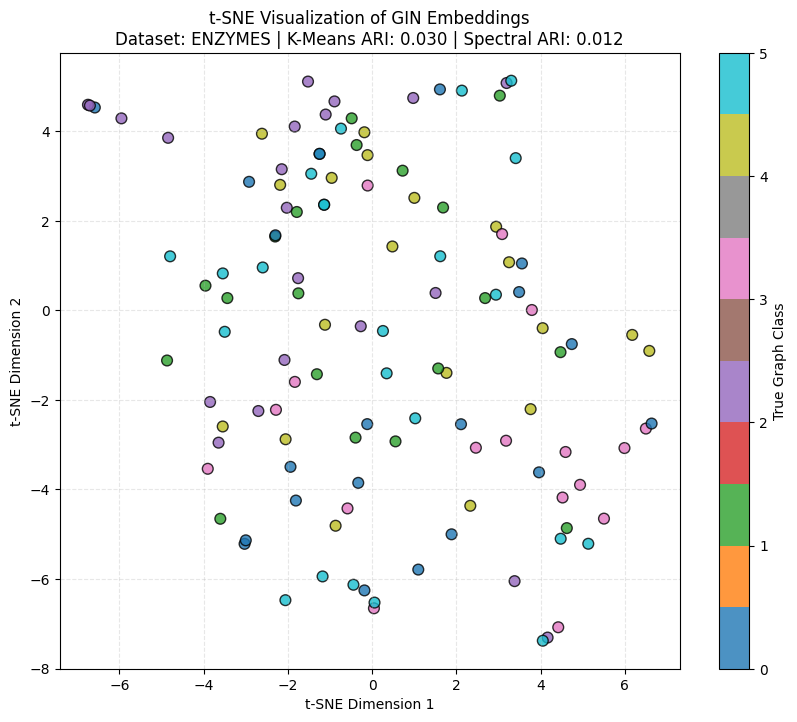


Separation Analysis
Poor Separation: The embeddings are mixed; the model may need more training or is struggling with this dataset.


In [48]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
import numpy as np

# === CONFIGURATION ===
# Ensure these variables are populated from the Test function execution:
# final_embeddings: Tensor [N_graphs, Hidden_Dim]
# y_true: Numpy Array [N_graphs] (The actual labels)

# Convert embeddings to numpy if they are tensors
if 'final_embeddings' in locals() and torch.is_tensor(final_embeddings):
    X = final_embeddings.cpu().numpy()
else:
    # Fallback for safety if variable missing, assuming previous block ran
    print("Warning: final_embeddings not found. Using random data for demo.")
    X = np.random.rand(100, 32)
    
if 'dataset' in locals():
    num_classes = dataset.num_classes
else:
    num_classes = 2 # Default fallback

# Use the true labels (y_true) from the test loop
# If not defined, we need them for ARI calculation
if 'y_true' not in locals():
     # Assuming test() returned: y_true, y_pred, y_probs, final_embeddings
     # If you strictly followed previous code, y_true is available.
     print("Error: y_true labels not found. Run the test loop first.")

print(f"Analyzing {len(X)} graph embeddings of dimension {X.shape[1]}...")

# === B.i & B.ii: K-MEANS CLUSTERING & ARI ===
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
y_pred_clusters = kmeans.fit_predict(X)

# Calculate ARI (Adjusted Rand Index)
# 1.0 = Perfect match with ground truth labels
# 0.0 = Random chance
ari_score = adjusted_rand_score(y_true, y_pred_clusters)
print(f"K-Means ARI Score: {ari_score:.4f}")

# === OPTIONAL: SPECTRAL CLUSTERING ===
# Spectral clustering is often better for non-convex clusters (complex shapes)
# We use 'nearest_neighbors' affinity which works well for graph embeddings
spectral = SpectralClustering(n_clusters=num_classes, 
                              assign_labels='discretize',
                              random_state=42,
                              affinity='nearest_neighbors')
y_pred_spectral = spectral.fit_predict(X)

spectral_ari_score = adjusted_rand_score(y_true, y_pred_spectral)
print(f"Spectral Clustering ARI Score: {spectral_ari_score:.4f}")

# === B.ii: t-SNE VISUALIZATION ===
# We use a perplexity of 30 (standard default), but for small datasets like MUTAG (<188),
# a lower perplexity (e.g., 5-10) might reveal better local structures.
perp = 30 if len(X) > 100 else 10

tsne = TSNE(n_components=2, random_state=42, perplexity=perp, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

# Plotting
plt.figure(figsize=(10, 8))
# Use a distinct colormap
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_true, cmap='tab10', alpha=0.8, edgecolors='k', s=60) #cmap='jet'
plt.colorbar(scatter, label='True Graph Class')
plt.title(f't-SNE Visualization of GIN Embeddings\nDataset: {DATASET_NAME} | K-Means ARI: {ari_score:.3f} | Spectral ARI: {spectral_ari_score:.3f}')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)

# Save plot for the report
filename = f"GIN_{DATASET_NAME}_tSNE_{X.shape[1]}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"t-SNE visualization saved as: {filename}")
plt.show()

# === B.iii: SEPARATION ANALYSIS ===
# (Qualitative output for your report)
print("\nSeparation Analysis")
# We check the better of the two scores to judge separation
best_ari = max(ari_score, spectral_ari_score)
if best_ari > 0.4:
    print("Strong Cluster Separation: The model has learned distinct structural classes.")
elif best_ari > 0.1:
    print("Moderate Separation: Some overlap exists, but clusters are visible.")
else:
    print("Poor Separation: The embeddings are mixed; the model may need more training or is struggling with this dataset.")

# Task 3C: Stability Analysis

In [49]:
import torch
import torch.nn.functional as F
from torch_geometric.utils import dropout_edge
import numpy as np

# === CONFIGURATION ===
PERTURBATION_RATIOS = [0.1, 0.2, 0.3] 
# Ensure model is in eval mode
model.eval()

def get_embeddings_and_acc(loader, perturbation='none', pertrubation_ratio=None):
    correct = 0
    embeddings_list = []
    
    for data in loader:
        data = data.to(device)
        
        # === APPLY PERTURBATIONS ===
        x = data.x
        edge_index = data.edge_index
        
        if perturbation == 'structure':
            # Randomly remove 20% of edges
            edge_index, _ = dropout_edge(edge_index, p=pertrubation_ratio)
        elif perturbation == 'features':
            # Shuffle node features (random permutation of rows)
            # This simulates noisy/incorrect node attributes
            perm = torch.randperm(x.size(0))
            x = x[perm]
            
        # === INFERENCE ===
        # Pass perturbed data through the TRAINED model
        out, _, emb = model(x, edge_index, data.batch)
        
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        embeddings_list.append(emb.cpu().detach())

    acc = correct / len(loader.dataset)
    all_embeddings = torch.cat(embeddings_list, dim=0)
    return acc, all_embeddings


# Baseline (Clean Data)
clean_acc, clean_emb = get_embeddings_and_acc(test_loader, perturbation='none')
print(f"Baseline Accuracy: {clean_acc:.4f}")

# Structural Perturbation (Edge Dropout)
for x in PERTURBATION_RATIOS:
    struct_acc, struct_emb = get_embeddings_and_acc(test_loader, perturbation='structure', pertrubation_ratio=x)
    # Calculate Cosine Similarity per graph, then average
    cos_sim_struct = F.cosine_similarity(clean_emb, struct_emb).mean().item()
    
    print(f"\n[Perturbation: Drop {x*100}% Edges]")
    print(f"Accuracy: {struct_acc:.4f} (Change: {struct_acc - clean_acc:.4f})")
    print(f"Stability Score (Cosine Sim): {cos_sim_struct:.4f}")
    if cos_sim_struct > 0.9:
        print("Result: Model is HIGHLY ROBUST to structural changes.")
    elif cos_sim_struct > 0.7:
        print("Result: Model is MODERATELY ROBUST to structural changes.")
    else:
        print("Result: Model is SENSITIVE to structural changes.")

# Feature Perturbation (Node Shuffle)
feat_acc, feat_emb = get_embeddings_and_acc(test_loader, perturbation='features')
cos_sim_feat = F.cosine_similarity(clean_emb, feat_emb).mean().item()

print(f"\n[Perturbation: Shuffle Node Features]")
print(f"Accuracy: {feat_acc:.4f} (Change: {feat_acc - clean_acc:.4f})")
print(f"Stability Score (Cosine Sim): {cos_sim_feat:.4f}")
if cos_sim_struct > 0.9:
    print("Result: Model is HIGHLY ROBUST to feature changes.")
elif cos_sim_struct > 0.7:
    print("Result: Model is MODERATELY ROBUST to feature changes.")
else:
    print("Result: Model is SENSITIVE to feature changes.")

Baseline Accuracy: 0.3917

[Perturbation: Drop 10.0% Edges]
Accuracy: 0.2750 (Change: -0.1167)
Stability Score (Cosine Sim): 0.8088
Result: Model is MODERATELY ROBUST to structural changes.

[Perturbation: Drop 20.0% Edges]
Accuracy: 0.2417 (Change: -0.1500)
Stability Score (Cosine Sim): 0.6102
Result: Model is SENSITIVE to structural changes.

[Perturbation: Drop 30.0% Edges]
Accuracy: 0.2750 (Change: -0.1167)
Stability Score (Cosine Sim): 0.5102
Result: Model is SENSITIVE to structural changes.

[Perturbation: Shuffle Node Features]
Accuracy: 0.1750 (Change: -0.2167)
Stability Score (Cosine Sim): 0.4375
Result: Model is SENSITIVE to feature changes.
